# 🧪 Practice Notebook – Topic 4

## Exercises / Ejercicios

### _Sequences, Series and Taylor Expansions_

**Instructions / Instrucciones:**

- Run each completed cell with `Shift+Enter` to check the results
- Reference code from the theory notebook when needed

---


## 📦 Setup — run this first / Ejecuta primero


In [2]:
# Uncomment if needed / Descomenta si es necesario
# !pip install sympy --quiet

import sympy as sp
from sympy import (
    symbols,
    Limit,
    oo,
    sin,
    cos,
    exp,
    log,
    sqrt,
    tan,
    atan,
    Sum,
    factorial,
    series,
    Rational,
    simplify,
    Abs,
    pi,
    I,
    asinh,
    diff,
    integrate,
)
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing(use_latex="mathjax")

n, x, alpha = symbols("n x alpha", real=True)
n_int = symbols("n", integer=True, positive=True)
n_pos = symbols("n", positive=True)

print("✅ Ready / Listo")

✅ Ready / Listo


---

## Block 1 / Bloque 1 — Limits of Sequences / Límites de Sucesiones

**Recall / Recuerda:** `Limit(expr, n, oo).doit()`


### Exercise 1.1 ⭐

Compute the following limits **by hand** first, then verify with SymPy.
_Calcula primero a mano, luego verifica con SymPy._

$$\lim_{n\to\infty}\frac{5n^3-3n+7}{2n^3+n^2-1}$$


In [11]:
# Define the expression and compute the limit
# Hint: divide numerator and denominator by n^3

expr_1_1 = (5 * n**3 - 3 * n + 7) / (2 * n**3 + n**2 - 1)

result_1_1 = Limit(expr_1_1, n, oo).doit()
print("Result:", result_1_1)
display(Limit(expr_1_1, n, oo))

Result: 5/2


    ⎛   3          ⎞
    ⎜5⋅n  - 3⋅n + 7⎟
lim ⎜──────────────⎟
n─→∞⎜   3    2     ⎟
    ⎝2⋅n  + n  - 1 ⎠

### Exercise 1.2 ⭐

$$\lim_{n\to\infty}\left(\sqrt{n^2+n} - n\right)$$

_Hint: multiply by the conjugate / Pista: multiplica por el conjugado._


In [10]:
# NOTE: use n_pos (positive symbol) to avoid SymPy sign issues
# NOTA: usa n_pos para evitar problemas de signo

expr_1_2 = sqrt(n_pos**2 + n_pos) - n_pos

result_1_2 = Limit(expr_1_2, n_pos, oo).doit()
print("Result:", result_1_2)

Result: 1/2


### Exercise 1.3 ⭐⭐

Limits of type $1^{\infty}$ / Límites de la forma $1^{\infty}$

$$\lim_{n\to\infty}\left(\frac{n+2}{n-1}\right)^{n}$$

_Hint: rewrite as $\left(1+\dfrac{3}{n-1}\right)^n$ and use $\lim\left(1+\frac{a}{n}\right)^n = e^a$_


In [9]:
expr_1_3 = ((n + 2) / (n - 1)) ** n

result_1_3 = Limit(expr_1_3, n, oo).doit()
print("Result:", result_1_3)
# Expected / Esperado: e^3

Result: exp(3)


### Exercise 1.4 ⭐⭐

$$\lim_{n\to\infty}\left(1+\frac{3}{n}\right)^{2n}$$


In [8]:
expr_1_4 = (1 + 3 / n) ** (2 * n)

print("Result:", Limit(expr_1_4, n, oo).doit())
# Expected / Esperado: e^6

Result: exp(6)


### Exercise 1.5 ⭐⭐

$$\lim_{n\to\infty}\left(\cos\frac{1}{n}\right)^{n^2}$$

_Hint: use Taylor $\cos u \approx 1 - u^2/2$ for small $u$_


In [7]:
expr_1_5 = cos(1 / n_pos) ** (n_pos**2)

print("Result:", Limit(expr_1_5, n_pos, oo).doit())
# Expected / Esperado: e^(-1/2) = 1/sqrt(e)

Result: exp(-1/2)


### Exercise 1.6 ⭐⭐ — Squeeze theorem / Teorema del emparedado

Prove that $\displaystyle\lim_{n\to\infty}\frac{(-1)^n\,n}{n^2+1}=0$ using the squeeze theorem, then compute:
$$\lim_{n\to\infty}\frac{n\cos(n^2+1)}{n^2+1}$$


In [12]:
# We know: |(-1)^n * n / (n^2+1)| = n/(n^2+1) <= 1/n -> 0
upper_bound = 1 / n_pos

print("Bound goes to 0:", Limit(upper_bound, n_pos, oo).doit())

# Part (b)
expr_1_6b = n_pos * cos(n_pos**2 + 1) / (n_pos**2 + 1)
# |cos(...)| <= 1, so |n*cos(...)/(n^2+1)| <= n/(n^2+1) -> 0
print("Result:", Limit(expr_1_6b, n_pos, oo).doit())

Bound goes to 0: 0
Result: 0


### Exercise 1.7 ⭐⭐⭐ — Recurrence / Sucesión recurrente

$$a_1 = 1, \quad a_{n+1} = \sqrt{2+a_n}$$

(a) Prove by induction that $a_n \le 2$ for all $n$.  
(b) Prove that $\{a_n\}$ is increasing.  
(c) Find $L = \lim a_n$.


In [13]:
# Numerical simulation
a = [1.0]
for _ in range(30):
    a.append((2 + a[-1]) ** 0.5)

print("First 10 terms:", [round(v, 6) for v in a[:10]])
print("a_30 =", round(a[-1], 10))

# L satisfies L = sqrt(2+L)  =>  L^2 - L - 2 = 0
L = symbols("L", positive=True)
eq = L**2 - L - 2
solutions = sp.solve(eq, L)
print("Solutions of L^2-L-2=0:", solutions)
print("Limit L =", [s for s in solutions if s > 0])

First 10 terms: [1.0, 1.732051, 1.931852, 1.98289, 1.995718, 1.998929, 1.999732, 1.999933, 1.999983, 1.999996]
a_30 = 2.0
Solutions of L^2-L-2=0: [2]
Limit L = [2]


---

## Block 2 / Bloque 2 — Numerical Series / Series Numéricas


### Exercise 2.1 ⭐ — Exact sums / Sumas exactas

Compute with SymPy and identify the closed form.


In [15]:
print("=== Exact sums / Sumas exactas ===")

# (a) Σ (2/3)^n  — geometric / geométrica
s_a = Sum(Rational(2, 3) ** n_int, (n_int, 0, oo))
print("(a) Σ (2/3)^n =", s_a.doit())

# (b) Σ (-1/3)^n
s_b = Sum((-Rational(1, 3)) ** n_int, (n_int, 0, oo))
print("(b) Σ (-1/3)^n =", s_b.doit())

# (c) Σ 2^n/n!  — recognise this! / ¡reconócela!
s_c = Sum(2**n_int / factorial(n_int), (n_int, 0, oo))
print("(c) Σ 2^n/n! =", s_c.doit())

# (d) Σ (n+3)/2^n
s_d = Sum((n_int + 3) / 2**n_int, (n_int, 0, oo))
print("(d) Σ (n+3)/2^n =", s_d.doit())

=== Exact sums / Sumas exactas ===
(a) Σ (2/3)^n = 3
(b) Σ (-1/3)^n = 3/4
(c) Σ 2^n/n! = exp(2)
(d) Σ (n+3)/2^n = 8


### Exercise 2.2 ⭐⭐ — D'Alembert ratio test / Criterio del cociente

Complete the `dalembert()` function and test all six series from the slides.


In [16]:
def dalembert(a_n_expr, var=n_int):
    """
    Apply D'Alembert ratio test.
    Returns (L, verdict) where L = lim |a_{n+1}/a_n|
    """
    ratio = simplify(a_n_expr.subs(var, var + 1) / a_n_expr)

    L = Limit(Abs(ratio), var, oo).doit()

    if L < 1:
        verdict = "CONVERGES / CONVERGE"
    elif L > 1:
        verdict = "DIVERGES / DIVERGE"
    else:
        verdict = "INCONCLUSIVE (L=1)"
    return L, verdict


test_series = [
    ("Σ 3^n/n!", 3**n_int / factorial(n_int)),
    ("Σ 2^n·n^2/n!", 2**n_int * n_int**2 / factorial(n_int)),
    ("Σ n!/n^n", factorial(n_int) / n_int**n_int),
    ("Σ 2^(n-2)/(n+1)", 2 ** (n_int - 2) / (n_int + 1)),
    ("Σ (-1)^n/(2n+1)!", (-1) ** n_int / factorial(2 * n_int + 1)),
    ("Σ n^n/n!", n_int**n_int / factorial(n_int)),
]

print("=== D'Alembert test ===")
for name, expr in test_series:
    L, v = dalembert(expr)
    print(f"  {name:22s}  L={L}  →  {v}")

=== D'Alembert test ===
  Σ 3^n/n!                L=0  →  CONVERGES / CONVERGE
  Σ 2^n·n^2/n!            L=0  →  CONVERGES / CONVERGE
  Σ n!/n^n                L=exp(-1)  →  CONVERGES / CONVERGE
  Σ 2^(n-2)/(n+1)         L=2  →  DIVERGES / DIVERGE
  Σ (-1)^n/(2n+1)!        L=0  →  CONVERGES / CONVERGE
  Σ n^n/n!                L=E  →  DIVERGES / DIVERGE


### Exercise 2.3 ⭐⭐ — Error estimation / Estimación del error

The series $S = \displaystyle\sum_{n=0}^{\infty}\frac{(-1)^n}{n!}$ converges to $e^{-1}$.

(a) Find the smallest $N$ such that $|S - S_N| < 10^{-4}$.  
(b) Compute $S_N$ and compare with $1/e$.


In [17]:
# By Leibniz: |S - S_N| < a_{N+1} = 1/(N+1)!
# We need (N+1)! > 10000

N = None
for k in range(1, 20):
    if float(factorial(k)) > 1e4:
        N = k - 1
        break

print(f"Smallest N = {N}")
print(f"  ({N+1})! = {int(factorial(N+1))} > 10000? {int(factorial(N+1)) > 10000}")

S_N = sum((-1) ** k / float(factorial(k)) for k in range(N + 1))
exact = float(sp.exp(-1).evalf())

print(f"S_{N} = {S_N:.10f}")
print(f"1/e   = {exact:.10f}")
print(f"Error = {abs(S_N - exact):.2e}  (< 1e-4: {abs(S_N - exact) < 1e-4})")

Smallest N = 7
  (8)! = 40320 > 10000? True
S_7 = 0.3678571429
1/e   = 0.3678794412
Error = 2.23e-05  (< 1e-4: True)


### Exercise 2.4 ⭐⭐ — Equivalences / Equivalencias

Study convergence using equivalent infinitesimals.  
_Recall: $1-\cos u \sim u^2/2$, $\log(1+u)\sim u$, $e^u-1\sim u$ as $u\to 0$._


In [18]:
def check_equivalence(name, a_n, b_n, var=n_pos):
    ratio = Limit(a_n / b_n, var, oo).doit()
    print(f"  {name}")
    print(f"    lim a_n/b_n = {ratio}")
    if ratio != 0 and ratio != oo:
        print(f"    → same character as Σ b_n")
    print()


# (a) Σ (1 - cos(1/n))  ~  Σ 1/(2n^2)
check_equivalence("Σ (1-cos(1/n))", 1 - cos(1 / n_pos), 1 / (2 * n_pos**2))

# (b) Σ log(1+1/n^2)
check_equivalence("Σ log(1+1/n^2)", log(1 + 1 / n_pos**2), 1 / n_pos**2)

# (c) Σ (e^(1/n)-1)/sqrt(n)
check_equivalence(
    "Σ (e^(1/n)-1)/sqrt(n)",
    (exp(1 / n_pos) - 1) / sqrt(n_pos),
    1 / n_pos ** sp.Rational(3, 2),
)

  Σ (1-cos(1/n))
    lim a_n/b_n = 1
    → same character as Σ b_n

  Σ log(1+1/n^2)
    lim a_n/b_n = 1
    → same character as Σ b_n

  Σ (e^(1/n)-1)/sqrt(n)
    lim a_n/b_n = 1
    → same character as Σ b_n



### Exercise 2.5 ⭐⭐⭐ — Complex series / Series complejas

$$\sum_{n=0}^{\infty}\frac{i^n}{3^n}, \qquad \sum_{n=0}^{\infty}\frac{2^n}{n!}, \qquad \sum_{n=0}^{\infty}\frac{e^{i\pi n/2}}{2^n}$$


In [19]:
# (a) Σ i^n / 3^n  — geometric r = i/3
s_a = Sum(I**n_int / 3**n_int, (n_int, 0, oo))
print("(a) Σ i^n/3^n =", sp.simplify(s_a.doit()))

# (b) Σ 2^n/n!
s_b = Sum(2**n_int / factorial(n_int), (n_int, 0, oo))
print("(b) Σ 2^n/n! =", s_b.doit())

# (c) Σ e^(iπn/2)/2^n   [hint: e^(iπ/2) = i]
s_c = Sum(I**n_int / 2**n_int, (n_int, 0, oo))
r_c = sp.simplify(s_c.doit())
print("(c) Σ e^(iπn/2)/2^n =", r_c, "≈", r_c.evalf())

(a) Σ i^n/3^n = 9/10 + 3*I/10
(b) Σ 2^n/n! = exp(2)
(c) Σ e^(iπn/2)/2^n = 4/5 + 2*I/5 ≈ 0.8 + 0.4*I


---

## Block 3 / Bloque 3 — Taylor Series / Series de Taylor

**Recall / Recuerda:** `series(f, x, x0, order)` — `order` is the first term **not** included.


### Exercise 3.1 ⭐ — Standard expansions / Desarrollos estándar

Compute and display the Taylor series at $x_0=0$ up to the given order.


In [20]:
print("=== Taylor series at x=0 ===")

expansions = [
    ("e^x", exp(x), 6),
    ("sin(x)", sin(x), 11),
    ("cos(x)", cos(x), 11),
    ("log(1+x)", log(1 + x), 8),
    ("arctan(x)", atan(x), 9),
    ("arcsinh(x)", asinh(x), 8),
]

for name, f, order in expansions:
    t = series(f, x, 0, order)
    print(f"\n{name}  (up to order {order-1}):")
    display(t)

=== Taylor series at x=0 ===

e^x  (up to order 5):


         2    3    4    5         
        x    x    x    x      ⎛ 6⎞
1 + x + ── + ── + ── + ─── + O⎝x ⎠
        2    6    24   120        


sin(x)  (up to order 10):


     3    5      7       9           
    x    x      x       x       ⎛ 11⎞
x - ── + ─── - ──── + ────── + O⎝x  ⎠
    6    120   5040   362880         


cos(x)  (up to order 10):


...

     2    3    4    5    6    7        
    x    x    x    x    x    x     ⎛ 8⎞
x - ── + ── - ── + ── - ── + ── + O⎝x ⎠
    2    3    4    5    6    7         


arctan(x)  (up to order 8):


     3    5    7        
    x    x    x     ⎛ 9⎞
x - ── + ── - ── + O⎝x ⎠
    3    5    7         


arcsinh(x)  (up to order 7):


     3      5      7        
    x    3⋅x    5⋅x     ⎛ 8⎞
x - ── + ──── - ──── + O⎝x ⎠
    6     40    112         

### Exercise 3.2 ⭐⭐ — Limits via Taylor / Límites mediante Taylor

**Method:** expand numerator and denominator, cancel leading terms.  
Complete the manual derivation **and** verify with SymPy.


In [21]:
limits_data = [
    ("(e^x-1-x)/x^2", (exp(x) - 1 - x) / x**2, sp.Rational(1, 2)),
    ("(cosx-1+x^2/2)/x^4", (cos(x) - 1 + x**2 / 2) / x**4, sp.Rational(1, 24)),
    ("(sinx-x)/x^3", (sin(x) - x) / x**3, sp.Rational(-1, 6)),
    ("(log(1+x)-x+x^2/2)/x^3", (log(1 + x) - x + x**2 / 2) / x**3, sp.Rational(1, 3)),
]

print("=== Limits via Taylor ===")
for name, expr, expected in limits_data:
    result = Limit(expr, x, 0).doit()
    ok = "✅" if result == expected else "❌"
    print(f"  lim {name} = {result}  (expected {expected}) {ok}")

=== Limits via Taylor ===
  lim (e^x-1-x)/x^2 = 1/2  (expected 1/2) ✅
  lim (cosx-1+x^2/2)/x^4 = 1/24  (expected 1/24) ✅
  lim (sinx-x)/x^3 = -1/6  (expected -1/6) ✅
  lim (log(1+x)-x+x^2/2)/x^3 = 1/3  (expected 1/3) ✅


### Exercise 3.3 ⭐⭐ — Products of series / Productos de series

Compute $T_4(x)$ of $h(x) = e^x \sin x$ **by multiplying** the expansions, then verify.


In [22]:
# Method 1: multiply T4 polynomials
T4_exp = series(exp(x), x, 0, 5).removeO()
T4_sin = series(sin(x), x, 0, 5).removeO()

product_manual = sp.Poly(T4_exp * T4_sin, x)
T4_product = sum(product_manual.nth(k) * x**k for k in range(5))

print("T_4(e^x sin x) via multiplication:")
display(sp.Eq(sp.Symbol("T_4"), T4_product))

# Method 2: direct SymPy
T4_direct = series(exp(x) * sin(x), x, 0, 5)
print("Direct SymPy:")
display(T4_direct)

print("Match:", sp.simplify(T4_product - T4_direct.removeO()) == 0)

T_4(e^x sin x) via multiplication:


      3         
     x     2    
T₄ = ── + x  + x
     3          

Direct SymPy:


          3        
     2   x     ⎛ 5⎞
x + x  + ── + O⎝x ⎠
         3         

Match: True


### Exercise 3.4 ⭐⭐ — Error bound / Cota de error

For $f(x) = \cos x$ at $x_0 = 0$:

(a) Compute $T_4(x)$.  
(b) Approximate $\cos(0.1)$ using $T_4$.  
(c) Bound $|E_4(0.1)| \le \dfrac{M_5}{5!}|0.1|^5$ where $M_5 = \max|f^{(5)}|$ on $[0, 0.1]$.  
(d) Compare with the actual error.


In [23]:
# (a) T_4(x) of cos(x)
T4_cos = series(cos(x), x, 0, 5)
T4_poly = T4_cos.removeO()
print("T_4(x) =", T4_poly)
display(T4_cos)

# (b) Approximate cos(0.1)
approx = float(T4_poly.subs(x, 0.1))
exact = float(sp.cos(sp.Rational(1, 10)).evalf())
print(f"\nT_4(0.1)  = {approx:.12f}")
print(f"cos(0.1)  = {exact:.12f}")

# (c) Error bound
# f^(5)(x) = -sin(x), max |f^(5)| on [0,0.1] <= sin(0.1) < 0.1
M5 = 0.1  # upper bound for |f^(5)| on [0, 0.1]
bound = M5 * (0.1) ** 5 / float(factorial(5))
actual_err = abs(exact - approx)

print(f"\nError bound  = {bound:.2e}")
print(f"Actual error = {actual_err:.2e}")
print(f"Bound holds: {actual_err <= bound}")

T_4(x) = x**4/24 - x**2/2 + 1


     2    4        
    x    x     ⎛ 5⎞
1 - ── + ── + O⎝x ⎠
    2    24        


T_4(0.1)  = 0.995004166667
cos(0.1)  = 0.995004165278

Error bound  = 8.33e-09
Actual error = 1.39e-09
Bound holds: True


### Exercise 3.5 ⭐⭐⭐ — Field of convergence / Campo de convergencia

Find the radius and interval of convergence (check endpoints!).


In [24]:
def radius(a_n_expr, var=n_int):
    r = Abs(a_n_expr / a_n_expr.subs(var, var + 1))
    return Limit(r, var, oo).doit()


cases = [
    ("Σ (-1)^n/n · x^n", (-1) ** n_int / n_int, 0, "(-1, 1]"),
    ("Σ (x+2)^n/(3^n√(n+1))", 1 / (3**n_int * sqrt(n_int + 1)), -2, "[-5, 1)"),
    ("Σ n! · x^n", factorial(n_int), 0, "{0}"),
    ("Σ x^n/(n·2^n)", 1 / (n_int * 2**n_int), 0, "[-2, 2)"),
]

print(f'{"Series":42s}  {"R":5s}  {"Interval (manual)"}')
print("-" * 65)
for name, a, centre, field in cases:
    R = radius(a)
    print(f"{name:42s}  R={str(R):4s}  {field}")

print("\n→ Verify endpoints manually / Verifica los extremos a mano")

Series                                      R      Interval (manual)
-----------------------------------------------------------------
Σ (-1)^n/n · x^n                            R=1     (-1, 1]
Σ (x+2)^n/(3^n√(n+1))                       R=3     [-5, 1)
Σ n! · x^n                                  R=0     {0}
Σ x^n/(n·2^n)                               R=2     [-2, 2)

→ Verify endpoints manually / Verifica los extremos a mano


### Exercise 3.6 ⭐⭐ — Derive from the geometric series / Derivar de la geométrica

Starting from $\displaystyle\frac{1}{1-x} = \sum x^n$, obtain:

(a) $\dfrac{1}{(1-x)^2}$ — differentiate  
(b) $\dfrac{x}{(1-x)^2}$ — multiply by $x$  
(c) $\log(1+x)$ — integrate $\frac{1}{1+x}$  
(d) $\arctan(x)$ — integrate $\frac{1}{1+x^2}$


In [25]:
print("=== Series derived from 1/(1-x) ===")

for name, f in [
    ("(a) 1/(1-x)^2", 1 / (1 - x) ** 2),
    ("(b) x/(1-x)^2", x / (1 - x) ** 2),
    ("(c) log(1+x)", log(1 + x)),
    ("(d) arctan(x)", atan(x)),
]:
    print(f"\n{name}:")
    display(series(f, x, 0, 8))

# Leibniz: arctan(1) = pi/4
print("\nLeibniz formula: arctan(1) =", sp.atan(1), "= pi/4")

=== Series derived from 1/(1-x) ===

(a) 1/(1-x)^2:


             2      3      4      5      6      7    ⎛ 8⎞
1 + 2⋅x + 3⋅x  + 4⋅x  + 5⋅x  + 6⋅x  + 7⋅x  + 8⋅x  + O⎝x ⎠


(b) x/(1-x)^2:


       2      3      4      5      6      7    ⎛ 8⎞
x + 2⋅x  + 3⋅x  + 4⋅x  + 5⋅x  + 6⋅x  + 7⋅x  + O⎝x ⎠


(c) log(1+x):


     2    3    4    5    6    7        
    x    x    x    x    x    x     ⎛ 8⎞
x - ── + ── - ── + ── - ── + ── + O⎝x ⎠
    2    3    4    5    6    7         


(d) arctan(x):


     3    5    7        
    x    x    x     ⎛ 8⎞
x - ── + ── - ── + O⎝x ⎠
    3    5    7         


Leibniz formula: arctan(1) = pi/4 = pi/4


### Exercise 3.7 ⭐⭐⭐ — Visualisation / Visualización

Plot $T_1, T_3, T_5, T_7$ of $\cos x$ on $[-3\pi, 3\pi]$ and show the error in log scale.


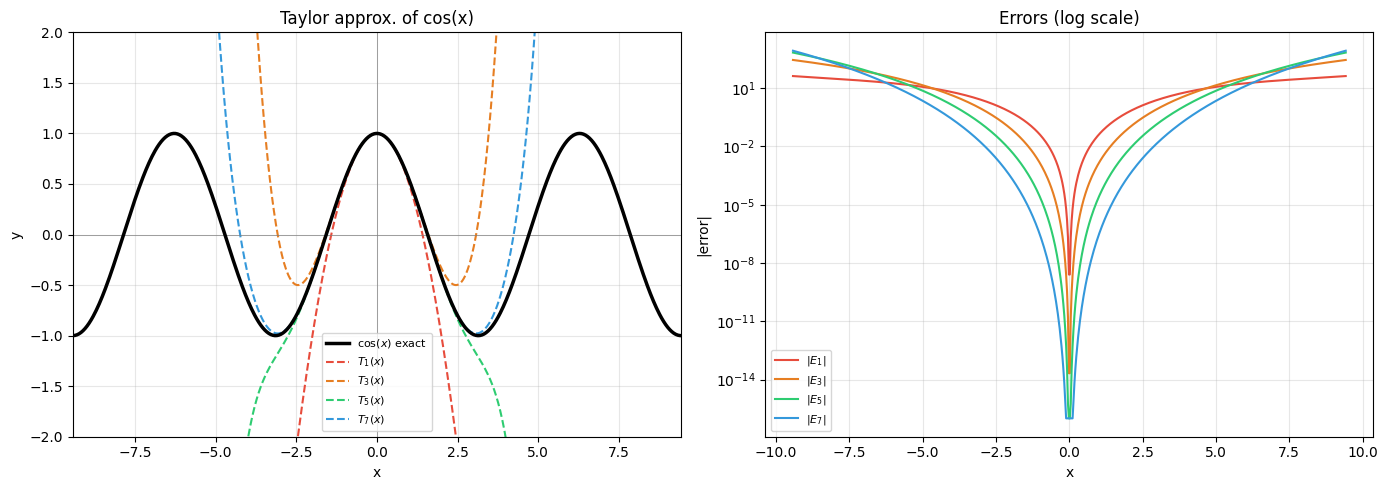

In [31]:
x_vals = np.linspace(-3 * np.pi, 3 * np.pi, 600)
exact = np.cos(x_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db"]
orders = [2, 4, 6, 8]  # cos: even powers only, so T_1=T_2, T_3=T_4...

# Left: approximations
ax = axes[0]
ax.plot(x_vals, exact, "k-", lw=2.5, label=r"$\cos(x)$ exact", zorder=5)
for order, color in zip(orders, colors):
    poly = series(cos(x), x, 0, order + 1).removeO()
    f_num = sp.lambdify(x, poly, "numpy")
    y = np.clip(f_num(x_vals), -3, 3)
    ax.plot(x_vals, y, "--", color=color, lw=1.5, label=f"$T_{{{order-1}}}(x)$")
ax.set(
    xlim=(-3 * np.pi, 3 * np.pi),
    ylim=(-2, 2),
    title="Taylor approx. of cos(x)",
    xlabel="x",
    ylabel="y",
)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)

# Right: errors in log scale
ax2 = axes[1]
for order, color in zip(orders, colors):
    poly = series(cos(x), x, 0, order + 1).removeO()
    f_num = sp.lambdify(x, poly, "numpy")
    err = np.abs(exact - f_num(x_vals))
    ax2.semilogy(
        x_vals,
        np.clip(err, 1e-16, None),
        color=color,
        lw=1.5,
        label=f"$|E_{{{order-1}}}|$",
    )
ax2.set(title="Errors (log scale)", xlabel="x", ylabel="|error|")
ax2.legend(fontsize=8)
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

---

## Block 4 / Bloque 4 — Mixed Challenges / Retos Mixtos ⭐⭐⭐


### Challenge 4.1 — Comparison / Comparación

$$\sum_{n=1}^\infty\left(1-\cos\frac{1}{n}\right), \quad \sum_{n=1}^\infty\frac{\sqrt[3]{n^4+1}}{\sqrt{n^5-2}}, \quad \sum_{n=2}^\infty\frac{1}{n(\log n)^2}$$


In [32]:
# (a) 1-cos(1/n) ~ 1/(2n^2)
print("(a)", Limit((1 - cos(1 / n_pos)) / (1 / (2 * n_pos**2)), n_pos, oo).doit())
# L=1, finite nonzero  =>  same character as Σ 1/n^2  => CONVERGES

# (b) (n^4+1)^(1/3) / (n^5-2)^(1/2)  ~  n^p  for some p
# Find the exponent p: 4/3 - 5/2 = -7/6
p = sp.Rational(-7, 6)
print(
    "(b)",
    Limit(
        (n_pos**4 + 1) ** sp.Rational(1, 3)
        / (n_pos**5 - 2) ** sp.Rational(1, 2)
        / n_pos**p,
        n_pos,
        oo,
    ).doit(),
)
# Since p < -1, Σ n^p converges, so the original series converges.

# (c) integral test: ∫_2^∞ 1/(t*(log t)^2) dt
t = symbols("t", positive=True)
integral_c = integrate(1 / (t * log(t) ** 2), (t, 2, oo))
print(
    "(c) integral =",
    integral_c,
    "=> CONVERGES" if integral_c.is_finite else "=> DIVERGES",
)

(a) 1
(b) 1
(c) integral = 1/log(2) => CONVERGES


### Challenge 4.2 — Estimating $\pi$ / Estimación de $\pi$

$$\frac{\pi}{4} = 1 - \frac{1}{3} + \frac{1}{5} - \cdots$$

(a) How many terms for 4 correct decimal places?  
(b) Plot the convergence.


Terms needed for 4 decimal places: 20000
  Estimate: 3.141543
  π exact:  3.141593


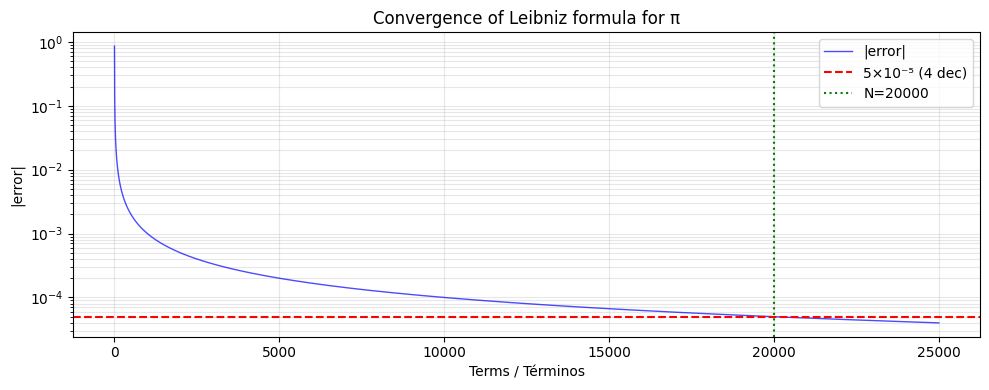

In [33]:
pi_exact = float(sp.pi)
errors = []
estimates = []
ns = list(range(1, 25001))
partial_sum = 0.0

for k in ns:
    i = k - 1
    partial_sum += 4 * (-1) ** i / (2 * i + 1)
    est = partial_sum
    estimates.append(est)
    errors.append(abs(est - pi_exact))

# (a)
N_4dec = next(k for k, e in enumerate(errors, 1) if e < 5e-5)
print(f"Terms needed for 4 decimal places: {N_4dec}")
print(f"  Estimate: {estimates[N_4dec-1]:.6f}")
print(f"  π exact:  {pi_exact:.6f}")

# (b)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(ns, errors, "b-", lw=1, alpha=0.7, label="|error|")
ax.axhline(5e-5, color="r", ls="--", lw=1.5, label="5×10⁻⁵ (4 dec)")
ax.axvline(N_4dec, color="g", ls=":", lw=1.5, label=f"N={N_4dec}")
ax.set(
    xlabel="Terms / Términos",
    ylabel="|error|",
    title="Convergence of Leibniz formula for π",
)
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### Challenge 4.3 — Auto-checker / Corrector automático 🤖

Complete `check_taylor_coeff()` so it verifies whether a given Taylor coefficient is correct.


In [34]:
def check_taylor_coeff(f_expr, n_order, claimed_coeff, x0=0):
    """
    Check if claimed_coeff equals the coefficient of (x-x0)^n_order
    in the Taylor series of f_expr at x0.
    """
    t = series(f_expr, x, x0, n_order + 1).removeO()
    correct = simplify(diff(f_expr, x, n_order).subs(x, x0) / factorial(n_order))

    is_correct = sp.simplify(correct - claimed_coeff) == 0
    status = "✅ Correct!" if is_correct else f"❌ Wrong! Correct: {correct}"
    print(f"  f={f_expr}, order={n_order}, claimed={claimed_coeff}  →  {status}")
    return is_correct


print("=== Correct answers / Respuestas correctas ===")
check_taylor_coeff(exp(x), 3, sp.Rational(1, 6))
check_taylor_coeff(sin(x), 5, sp.Rational(1, 120))
check_taylor_coeff(cos(x), 4, sp.Rational(1, 24))
check_taylor_coeff(log(1 + x), 3, sp.Rational(1, 3))

print("\n=== Wrong answers / Respuestas incorrectas ===")
check_taylor_coeff(sin(x), 4, sp.Rational(1, 24))  # sin has no x^4
check_taylor_coeff(cos(x), 3, sp.Rational(-1, 6))  # cos has no x^3

=== Correct answers / Respuestas correctas ===
  f=exp(x), order=3, claimed=1/6  →  ✅ Correct!
  f=sin(x), order=5, claimed=1/120  →  ✅ Correct!
  f=cos(x), order=4, claimed=1/24  →  ✅ Correct!
  f=log(x + 1), order=3, claimed=1/3  →  ✅ Correct!

=== Wrong answers / Respuestas incorrectas ===
  f=sin(x), order=4, claimed=1/24  →  ❌ Wrong! Correct: 0
  f=cos(x), order=3, claimed=-1/6  →  ❌ Wrong! Correct: 0


False

---

## 📝 Quick Reference / Referencia rápida

| Task            | SymPy                            | Notes                                              |
| --------------- | -------------------------------- | -------------------------------------------------- |
| Sequence limit  | `Limit(expr, n, oo).doit()`      | Use `n_pos` with `sqrt`                            |
| Infinite series | `Sum(expr, (n, 0, oo)).doit()`   | Check absolute value of ratio for geometric series |
| D'Alembert      | `Limit(Abs(a(n+1)/a(n)), n, oo)` | Simplify ratio first                               |
| Taylor          | `series(f, x, x0, order)`        | Order is **exclusive**                             |
| Strip O()       | `.removeO()`                     | Then `.subs(x, val)`                               |
| Error bound     | $M \cdot h^{n+1}/(n+1)!$         | $M$ bounds the next derivative                     |
| Radius          | `Limit(Abs(a_n/a_{n+1}), n, oo)` | Check endpoints separately                         |

**Notebook completed / Cuaderno completado:**  
_All exercise cells have been filled in._
